# Praktika: Naive Bayes

## 0. Ariketa: Aurre-ebaluazioa
Hurrengo [datu-bilduma](https://drive.google.com/file/d/1cX5QnIu3RnfEyM66aatOJDYvhx7xRf66/view?usp=sharing) izanda. Hurrengo galderak erantzun.
1. Zein da Spam izatearen probabilitatea?
2. Zein da Ham izatearen probabilitatea?

In [1]:
## importak

import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from gensim.models.word2vec import Word2Vec
from sklearn.model_selection import train_test_split
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer 
from nltk.corpus import wordnet
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
import seaborn as sns


In [2]:
## datu bilduma kargatu
df = pd.read_csv('spamhamdata.csv', sep='\t', quoting=3, header=None, names=['Klaseak', 'Datuak'])
df.tail()

,Klaseak,Datuak
5569,spam,This is the 2nd time we have tried 2 contact u...
5570,ham,Will ü b going to esplanade fr home?
5571,ham,"Pity, * was in mood for that. So...any other s..."
5572,ham,The guy did some bitching but I acted like i'd...
5573,ham,Rofl. Its true to its name


In [3]:
## probabilitateak atera

kont = df['Klaseak'].value_counts()
prob_spam = kont['spam'] / len(df)*100
prob_ham = kont['ham'] / len(df)*100

print(f'Probabilitatea spam: %{prob_spam}')
print(f'Probabilitatea ham: %{prob_ham}')

Probabilitatea spam: %13.40150699677072
Probabilitatea ham: %86.59849300322928


### Testu zarata kendu

In [4]:
## testu garbiketa

df2 = df.copy()
df2['Datuak'] = df2['Datuak']

print(df['Datuak'][13])

def garbitu_testua(testua):

    # minuskulak bihurtu
    testua = testua.lower()

    # url kendu
    testua = re.sub(r'http\S+|www\S+|https\S+', '', testua, flags=re.MULTILINE)

    # kendu zenbakiak duten hitzak
    testua = re.sub(r"\w*\d\w*", "", testua)

    # karaktere bereziak kendu
    testua = re.sub(r"[^'a-z\s]", "", testua)

    # kendu gehiegizko hutsuneak
    testua = re.sub(r"\s+", " ", testua).strip()
    
    return testua

# testua paragrafoka
df2['Datuak'] = [garbitu_testua(df2['Datuak'][index]) for index in range(len(df2['Datuak']))]
print(df2['Datuak'][13])

I've been searching for the right words to thank you for this breather. I promise i wont take your help for granted and will fulfil my promise. You have been wonderful and a blessing at all times.
i've been searching for the right words to thank you for this breather i promise i wont take your help for granted and will fulfil my promise you have been wonderful and a blessing at all times


In [5]:
print(df2['Datuak'][13])

# Decontract English contractions
contractions = {
    "ain\'t": "are not", "aren\'t": "are not", "can\'t": "can not", "can\'t\'ve": "can not have",
    "could\'ve": "could have", "couldn\'t": "could not", "couldn\'t\'ve": "could not have",
    "didn\'t": "did not", "doesn\'t": "does not", "don\'t": "do not", "hadn\'t": "had not",
    "hadn\'t\'ve": "had not have", "hasn\'t": "has not", "haven\'t": "have not",
    "he\'d": "he would", "he\'d\'ve": "he would have", "he\'ll": "he will", "he\'s": "he is",
    "how\'d": "how did", "how\'ll": "how will", "how\'s": "how is", "i\'d": "i would",
    "i\'d\'ve": "i would have", "i\'ll": "i will", "i\'m": "i am", "i\'ve": "i have",
    "isn\'t": "is not", "it\'d": "it would", "it\'d\'ve": "it would have", "it\'ll": "it will",
    "it\'s": "it is", "let\'s": "let us", "ma\'am": "madam", "might\'ve": "might have",
    "mightn\'t": "might not", "must\'ve": "must have", "mustn\'t": "must not",
    "needn\'t": "need not", "shan\'t": "shall not", "she\'d": "she would",
    "she\'d\'ve": "she would have", "she\'ll": "she will", "she\'s": "she is",
    "should\'ve": "should have", "shouldn\'t": "should not", "that\'d": "that would",
    "that\'s": "that is", "there\'d": "there would", "there\'s": "there is",
    "they\'d": "they would", "they\'ll": "they will", "they\'re": "they are",
    "they\'ve": "they have", "wasn\'t": "was not", "we\'d": "we would",
    "we\'ll": "we will", "we\'re": "we are", "we\'ve": "we have", "weren\'t": "were not",
    "what\'ll": "what will", "what\'re": "what are", "what\'s": "what is",
    "what\'ve": "what have", "when\'s": "when is", "where\'d": "where did",
    "where\'s": "where is", "who\'ll": "who will", "who\'s": "who is",
    "won\'t": "will not", "wouldn\'t": "would not", "you\'d": "you would",
    "you\'ll": "you will", "you\'re": "you are", "you\'ve": "you have"
}

# Replace contractions
def replace_contractions(text):
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    return text

df2['Datuak'] = df2['Datuak'].apply(replace_contractions)

print(df2['Datuak'][13])

i've been searching for the right words to thank you for this breather i promise i wont take your help for granted and will fulfil my promise you have been wonderful and a blessing at all times
i have been searching for the right words to thank you for this breather i promise i wont take your help for granted and will fulfil my promise you have been wonderful and a blessing at all times


### Tokenizazioa

In [6]:
# nltk kargatu
nltk.download('stopwords') 
nltk.download('punkt') 
nltk.download('punkt_tab') 

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return tokens


# testua tokenizatu
df2['Datuak'] = [preprocess_text(p) for p in df2['Datuak']]

len(df2['Datuak'])
print(df2['Datuak'])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ehernaiz\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ehernaiz\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ehernaiz\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


0       [go, jurong, point, crazy, available, bugis, n...
1                          [ok, lar, joking, wif, u, oni]
2       [free, entry, wkly, comp, win, fa, cup, final,...
3           [u, dun, say, early, hor, u, c, already, say]
4          [nah, think, goes, usf, lives, around, though]
                              ...                        
5569    [time, tried, contact, u, u, pound, prize, cla...
5570                      [b, going, esplanade, fr, home]
5571                     [pity, mood, soany, suggestions]
5572    [guy, bitching, acted, like, would, interested...
5573                                   [rofl, true, name]
Name: Datuak, Length: 5574, dtype: object


### Word2Vec

In [7]:
model = Word2Vec(
    sentences=df2['Datuak'],
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    epochs=30
)

### Normalizazioa

## 1. Ariketa: Testu prozesamendua
Word2Vec erabiliz, hurrengo galderak erantzun.
1. Zenbat da 'winner' eta 'mobile' hitzen arteko erlazioa?
2. Zein dira 'coffee' hitzarekin lotura gehien daukaten 5 hitzak?

In [8]:
## winner mobile
try:
    similarity_m_e = model.wv.similarity('winner', 'mobile')
    print(f" 'winner' and 'mobile' arteko similaritatea: {similarity_m_e:.4f}")
except KeyError as e:
    print(f"KeyError: {e}")

 'winner' and 'mobile' arteko similaritatea: 0.4264


In [9]:
## coffee
try:
    similar_words_coffee = model.wv.most_similar('coffee', topn=5)
    print("Most similar words to 'coffee':")
    print(*similar_words_coffee, sep='\n')
except KeyError as e:
    print(f"KeyError: {e}")

Most similar words to 'coffee':
('darlings', 0.8278826475143433)
('tomocan', 0.7981556057929993)
('wld', 0.7642315030097961)
('amk', 0.7641841173171997)
('reminds', 0.7561461925506592)


## 2. Ariketa: Modelo sorrera eta ebaluazioa

Naive Bayes erabiliz, iragarpen modelo bat sortu.

Hurrengo galdera erantzun.

> Zein Naive Bayes erabiliko duzu. Zergatik?

> Naive Bayes Multinomial erabiliko dut testua sailkatzeko mota onena delako, eta gure kasuan testua prozesatu behar du spam edo ham dela esateko.

In [10]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ehernaiz\AppData\Roaming\nltk_data...


True

In [11]:
## lemmatizazioa egin
dfLem = df.copy()
dfLem['Datuak'] = df2['Datuak']
print(dfLem.tail())

lemmatizer = WordNetLemmatizer()
def lemma_egin(paragrafoa):
    return [lemmatizer.lemmatize(w) for w in paragrafoa]

datuakLem = [lemma_egin(p) for p in dfLem['Datuak']]
print(dfLem.tail())

     Klaseak                                             Datuak
5569    spam  [time, tried, contact, u, u, pound, prize, cla...
5570     ham                    [b, going, esplanade, fr, home]
5571     ham                   [pity, mood, soany, suggestions]
5572     ham  [guy, bitching, acted, like, would, interested...
5573     ham                                 [rofl, true, name]
     Klaseak                                             Datuak
5569    spam  [time, tried, contact, u, u, pound, prize, cla...
5570     ham                    [b, going, esplanade, fr, home]
5571     ham                   [pity, mood, soany, suggestions]
5572     ham  [guy, bitching, acted, like, would, interested...
5573     ham                                 [rofl, true, name]


In [12]:
## dataseta prestatu, 80/20 banaketa
dfPrestatu = dfLem.copy()
dfPrestatu['Datuak'] = datuakLem

def test (df, ehuneko):
    tamaina = len (df)
    test_tamaina = int (tamaina * ehuneko)
    df_test = df[:test_tamaina]
    df_train = df[test_tamaina:]
    return df_train, df_test

df_train, df_test = test (dfPrestatu, 0.2)

# Klaseak banatu
X = dfPrestatu['Datuak']
y = dfPrestatu['Klaseak']

X = X.apply(" ".join)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
## bektorizazioa egin

bektorizadorea = TfidfVectorizer()

X_train = bektorizadorea.fit_transform(X_train)
X_test = bektorizadorea.transform(X_test)


In [14]:
## modeloa kargatu
clf = MultinomialNB()
clf.fit(X_train, Y_train)
y_pred = clf.predict(X_test)


F1 Score (macro) PCA: 0.9256
F1 Score (micro) PCA: 0.9256


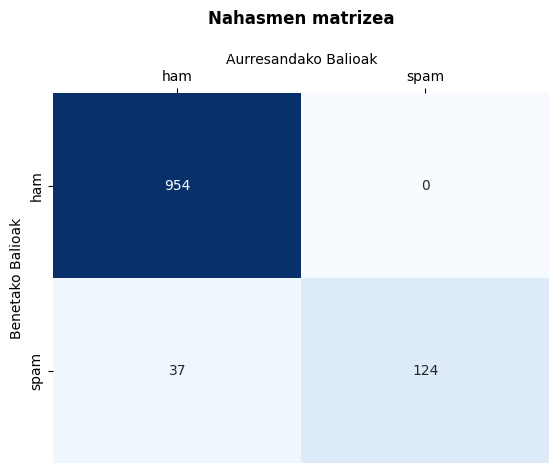

In [15]:
## modelo ebaluazioa

cm_pca = confusion_matrix(Y_test, y_pred)

# Erakutsi matrizea 
ax2= sns.heatmap(
    cm_pca,
    annot=True,
    fmt="d",
    cmap='Blues',
    cbar=False,
)

ax2.set_title('Nahasmen matrizea\n', fontweight="bold")

ax2.xaxis.tick_top()
ax2.xaxis.set_label_position('top')

ax2.set_xlabel('Aurresandako Balioak')
ax2.set_ylabel('Benetako Balioak')

ax2.xaxis.set_ticklabels(['ham', 'spam'])
ax2.yaxis.set_ticklabels(['ham', 'spam'])

# F1 
f1_macro = f1_score(Y_test, y_pred, average='macro')
f1_micro = f1_score(Y_test, y_pred, average='micro')

print(f"\nF1 Score (macro) PCA: {f1_macro:.4f}")
print(f"F1 Score (micro) PCA: {f1_macro:.4f}")


## Ondorioak

Spam eta ham mezuak sailkatzeko Naive Bayes eredu bat sortu dut.

### Egindakoa labur

**Testua garbitu**: Ezabatu URLak, karaktere bereziak, minuskulak egin, eta stop words kendu. Hori dena oso teditsua, baina garrantzitsua.

**Word2Vec**: Hitzak bektore gisa irudikatu dut. Hitzak zenbakitan bihurtu, esangura duenak. Horrela ikusi hitzen arteko erlazioa.

**Naive Bayes eredua**: Multinomial erabiltzea erabaki genuen. TF-IDF erabiliz beste bektoreetean bihurt eta 80/20 banaketa eginezkero entrenatu dut.

### Emaitzak

Eredua ondo funtzionatzen du. Matrizea eta F1 scorea erakusten du nolakoa den.

### Zer ikasi dut

- Datu garbiak = eredu hobea  
- Naive Bayes sinplea eta funtzionala  
- TF-IDF + Naive Bayes konbinaketa on 

Laburtzeko, modeloak bere lana egiten du. Perfektua ez bada ere, spam detekziorako nahiko ondo funtzionatzen du, hala ere ikusten denez spam mezuak askoz gutxiago dira.